# Simulation study



In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvinecopulib as pv

from tabpfn.constants import ModelVersion
from npcc import PFNRBicop

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Scenario 1

Simulate copula data from a Clayton copula with Kendall's $\tau$ depending on $x$ through the identity, i.e.
$$
 \tau(x) = x,
$$

for $x \in [0.01, 0.99]$.

In [3]:
def sample_scenario_1(
    n: int = 1000,
    x_min: float = 0.01,
    x_max: float = 0.99,
    seed: int = 317
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    x = np.linspace(x_min, x_max, n, dtype=np.float64)
    theta = 2.0 * x / (1.0 - x)

    eps = 1e-12
    u = rng.uniform(eps, 1.0 - eps, size=n)
    w = rng.uniform(eps, 1.0 - eps, size=n)

    # Stable inverse conditional-CDF sampler for Clayton with pair-specific theta(x).
    # Using v = u * B^(-1/theta), where B = w^(-theta/(theta+1)) - 1 + u^theta.
    log_u = np.log(u)
    log_w = np.log(w)
    log_w_term = (-theta / (theta + 1.0)) * log_w
    w_term = np.exp(log_w_term)
    u_theta = np.exp(theta * log_u)
    base = w_term - 1.0 + u_theta
    base = np.maximum(base, eps)
    log_v = log_u - np.log(base) / theta
    v = np.exp(log_v)

    return pd.DataFrame({"u": u, "v": v, "x": x})

In [4]:
x_eval = np.linspace(0.01, 0.99, 50)

uv_pairs = [
    (0.1, 0.1), (0.1, 0.3), (0.1, 0.5), (0.1, 0.7), (0.1, 0.9),
    (0.3, 0.1), (0.3, 0.3), (0.3, 0.5), (0.3, 0.7), (0.3, 0.9),
    (0.5, 0.1), (0.5, 0.3), (0.5, 0.5), (0.5, 0.7), (0.5, 0.9),
    (0.7, 0.1), (0.7, 0.3), (0.7, 0.5), (0.7, 0.7), (0.7, 0.9),
    (0.9, 0.1), (0.9, 0.3), (0.9, 0.5), (0.9, 0.7), (0.9, 0.9)
]

def clayton_theta(x_vals: np.ndarray) -> np.ndarray:
    return 2.0 * x_vals / (1.0 - x_vals)

theta_eval = clayton_theta(x_eval)

def clayton_pdf_true(u_val: float, v_val: float, theta: np.ndarray) -> np.ndarray:
    log_u = np.log(u_val)
    log_v = np.log(v_val)

    log_u_neg_theta = -theta * log_u
    log_v_neg_theta = -theta * log_v
    max_log_term = np.maximum(log_u_neg_theta, log_v_neg_theta)
    sum_core = (
        np.exp(log_u_neg_theta - max_log_term)
        + np.exp(log_v_neg_theta - max_log_term)
        - np.exp(-max_log_term)
    )

    log_sum_term = max_log_term + np.log(sum_core)
    log_pdf_true = (
        np.log(theta + 1.0)
        + (-theta - 1.0) * (log_u + log_v)
        + (-2.0 - 1.0 / theta) * log_sum_term
    )
    return np.exp(log_pdf_true)

def clayton_cdf_true(u_val: float, v_val: float, theta: np.ndarray) -> np.ndarray:
    log_u = np.log(u_val)
    log_v = np.log(v_val)

    log_u_neg_theta = -theta * log_u
    log_v_neg_theta = -theta * log_v
    max_log_term = np.maximum(log_u_neg_theta, log_v_neg_theta)
    sum_core = (
        np.exp(log_u_neg_theta - max_log_term)
        + np.exp(log_v_neg_theta - max_log_term)
        - np.exp(-max_log_term)
    )

    log_sum_term = max_log_term + np.log(sum_core)
    log_cdf_true = (-1.0 / theta) * log_sum_term
    return np.exp(log_cdf_true)

def clayton_hfunc1_true(u_val: float, v_val: float, theta: np.ndarray) -> np.ndarray:
    log_u = np.log(u_val)
    log_v = np.log(v_val)

    log_u_neg_theta = -theta * log_u
    log_v_neg_theta = -theta * log_v
    max_log_term = np.maximum(log_u_neg_theta, log_v_neg_theta)
    sum_core = (
        np.exp(log_u_neg_theta - max_log_term)
        + np.exp(log_v_neg_theta - max_log_term)
        - np.exp(-max_log_term)
    )

    log_sum_term = max_log_term + np.log(sum_core)
    log_hfunc1_true = (-theta - 1.0) * log_u + (-1.0 / theta - 1.0) * log_sum_term
    return np.exp(log_hfunc1_true)

def clayton_hfunc2_true(u_val: float, v_val: float, theta: np.ndarray) -> np.ndarray:
    log_u = np.log(u_val)
    log_v = np.log(v_val)

    log_u_neg_theta = -theta * log_u
    log_v_neg_theta = -theta * log_v
    max_log_term = np.maximum(log_u_neg_theta, log_v_neg_theta)
    sum_core = (
        np.exp(log_u_neg_theta - max_log_term)
        + np.exp(log_v_neg_theta - max_log_term)
        - np.exp(-max_log_term)
    )

    log_sum_term = max_log_term + np.log(sum_core)
    log_hfunc2_true = (-theta - 1.0) * log_v + (-1.0 / theta - 1.0) * log_sum_term
    return np.exp(log_hfunc2_true)


def precompute_true_curves(uv_pairs: list[tuple[float, float]], theta: np.ndarray) -> dict:
    true_curves = {}
    for u_val, v_val in uv_pairs:
        true_curves[(u_val, v_val)] = {
            "pdf": clayton_pdf_true(u_val, v_val, theta),
            "cdf": clayton_cdf_true(u_val, v_val, theta),
            "hfunc1": clayton_hfunc1_true(u_val, v_val, theta),
            "hfunc2": clayton_hfunc2_true(u_val, v_val, theta),
        }
    return true_curves


TRUE_CURVES = precompute_true_curves(uv_pairs, theta_eval)

# One-time batched evaluation grids reused across all repetitions.
N_PAIRS = len(uv_pairs)
N_X = len(x_eval)

U_PAIR = np.asarray([u for u, _ in uv_pairs], dtype=np.float64)
V_PAIR = np.asarray([v for _, v in uv_pairs], dtype=np.float64)

U_EVAL_GRID = np.repeat(U_PAIR[:, None], N_X, axis=1)
V_EVAL_GRID = np.repeat(V_PAIR[:, None], N_X, axis=1)
X_EVAL_GRID = np.repeat(x_eval[None, :], N_PAIRS, axis=0)

U_EVAL_FLAT = U_EVAL_GRID.reshape(-1)
V_EVAL_FLAT = V_EVAL_GRID.reshape(-1)
X_EVAL_FLAT = X_EVAL_GRID.reshape(-1)

TRUE_PDF_GRID = np.stack([TRUE_CURVES[(u, v)]["pdf"] for u, v in uv_pairs], axis=0)
TRUE_CDF_GRID = np.stack([TRUE_CURVES[(u, v)]["cdf"] for u, v in uv_pairs], axis=0)
TRUE_HFUNC1_GRID = np.stack([TRUE_CURVES[(u, v)]["hfunc1"] for u, v in uv_pairs], axis=0)
TRUE_HFUNC2_GRID = np.stack([TRUE_CURVES[(u, v)]["hfunc2"] for u, v in uv_pairs], axis=0)

## Error metrics used for model-vs-truth comparison

For each fixed pair $(u,v)$, we compare the estimated curve $\hat{f}(x)$ to the true curve $f(x)$ over the grid `x_eval`.

Let $e(x)=\hat{f}(x)-f(x)$.

- **MAE (mean absolute error)**: $\frac{1}{m}\sum_{j=1}^m |e(x_j)|$
- **RMSE (root mean squared error)**: $\sqrt{\frac{1}{m}\sum_{j=1}^m e(x_j)^2}$
- **MaxAE (maximum absolute error)**: $\max_j |e(x_j)|$
- **IAE (integrated absolute error)**: $\int |e(x)|\,dx$ (numerically via trapezoid rule)
- **ISE (integrated squared error)**: $\int e(x)^2\,dx$ (numerically via trapezoid rule)
- **MRAE (mean relative absolute error)**: $\frac{1}{m}\sum_{j=1}^m \frac{|e(x_j)|}{|f(x_j)|+\varepsilon}$
- **KL distance (PDF only, normalized over x)**:
  First normalize over `x_eval`: $p(x)=\frac{f(x)}{\int f},\; q(x)=\frac{\hat f(x)}{\int \hat f}$, then
  $$
  D_{KL}(p\,\|\,q)=\int p(x)\log\frac{p(x)}{q(x)}\,dx
  $$

We report metrics per $(u,v)$ pair, then aggregate across all pairs with mean, median, 95th percentile, and max.

## Multi-repetition study across sample sizes

The previous metrics chunk is kept as the **single-repetition showcase**.

This section repeats the simulation for multiple sample sizes and repetitions, then aggregates performance across repetitions.

Default start values:

- `N_REP = 20`
- `N_LIST = [200, 500, 1000]`

Outputs from this section:

- `rep_results_long`: per-repetition summary metrics (already aggregated over `(u, v)` pairs within each repetition)
- `mc_summary`: aggregated performance over repetitions
- `runtime_summary`: runtime aggregation over repetitions

In [5]:
from Simulation_Study_helpers import run_repetitions, aggregate_results, curve_metrics, plot_metric_uv_boxgrid, plot_all_uv_metric_boxgrids, plot_all_avg_uv_metric_boxplots, average_over_uv_pairs, plot_runtime_components_boxplot, plot_conditional_curves_by_uv

In [20]:
rep_results, pointwise_results, runtime, wall = run_repetitions(
    n_list=[200, 500, 1000],
    n_rep=20,
    base_seed=42,
    num_workers=2,

    device=device,
    sample_scenario_1=sample_scenario_1,
    curve_metrics=curve_metrics,
    PFNRBicop=PFNRBicop,

    U_EVAL_FLAT=U_EVAL_FLAT,
    V_EVAL_FLAT=V_EVAL_FLAT,
    X_EVAL_FLAT=X_EVAL_FLAT,

    TRUE_PDF_GRID=TRUE_PDF_GRID,
    TRUE_CDF_GRID=TRUE_CDF_GRID,
    TRUE_HFUNC1_GRID=TRUE_HFUNC1_GRID,
    TRUE_HFUNC2_GRID=TRUE_HFUNC2_GRID,

    uv_pairs=uv_pairs,
    x_eval=x_eval,
    N_PAIRS=N_PAIRS,
    N_X=N_X,
)

In [21]:
mc_summary_long, mc_summary_wide, runtime_summary_long, runtime_summary_wide = (
    aggregate_results(rep_results, runtime)
)

In [30]:
display(runtime_summary_long)

,model,n,fit_time_mean,fit_time_std,fit_time_p95,pdf_time_mean,pdf_time_std,pdf_time_p95,cdf_time_mean,cdf_time_std,cdf_time_p95,h1_time_mean,h1_time_std,h1_time_p95,h2_time_mean,h2_time_std,h2_time_p95,total_model_time_mean,total_model_time_std,total_model_time_p95
0,V2.5,200,0.476685,0.102848,0.753009,1.242847,0.078753,1.367215,11.762111,0.753231,13.583590,0.618850,0.035795,0.678700,0.605546,0.043066,0.635780,14.717264,0.869213,16.897624
1,V2.5,500,0.520663,0.085377,0.679638,1.238033,0.103461,1.373335,12.268094,0.662425,13.176733,0.626470,0.039839,0.708850,0.631541,0.045970,0.708795,15.296485,0.797611,16.572717
2,V2.5,1000,0.617235,0.043952,0.667242,1.625472,0.306638,2.048713,15.816137,1.830538,17.085553,0.760097,0.164749,0.949107,0.756308,0.145376,0.947341,19.587086,2.161306,20.980024
3,V3,200,1.888270,0.488813,2.986979,2.073409,0.140157,2.263145,21.327136,0.731950,22.207278,1.027208,0.078866,1.135989,1.031989,0.089862,1.165537,27.359217,1.009190,28.518170
4,V3,500,1.895464,0.194845,2.153008,2.250651,0.167692,2.415905,23.191772,1.126052,24.406870,1.104969,0.110421,1.315601,1.073884,0.134787,1.246677,29.528508,1.290630,31.737804
5,V3,1000,2.045868,0.331860,2.550325,2.525396,0.289209,2.795198,23.213897,2.187845,25.058925,1.259475,0.116815,1.390408,1.262845,0.132797,1.376751,30.319856,2.754912,32.429094


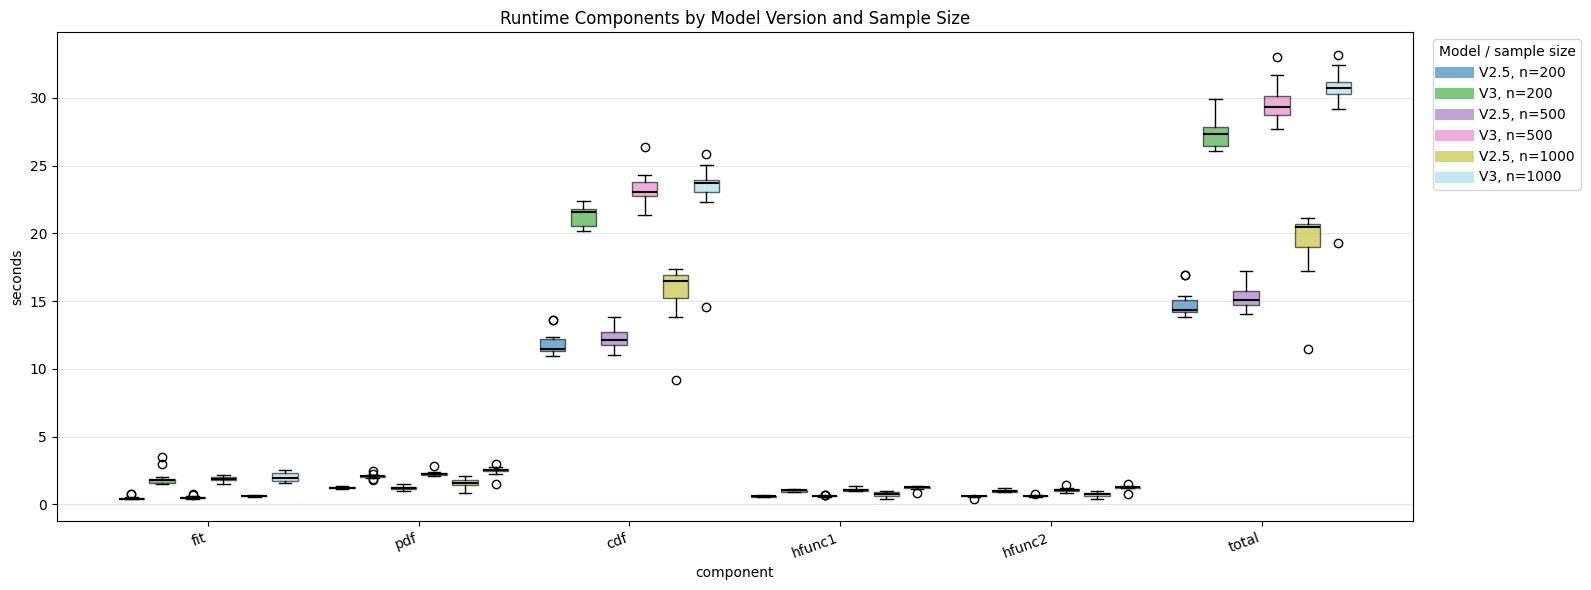

In [23]:
fig, ax = plot_runtime_components_boxplot(
    runtime,
    model_order=["V2.5", "V3"],
)

plt.show()

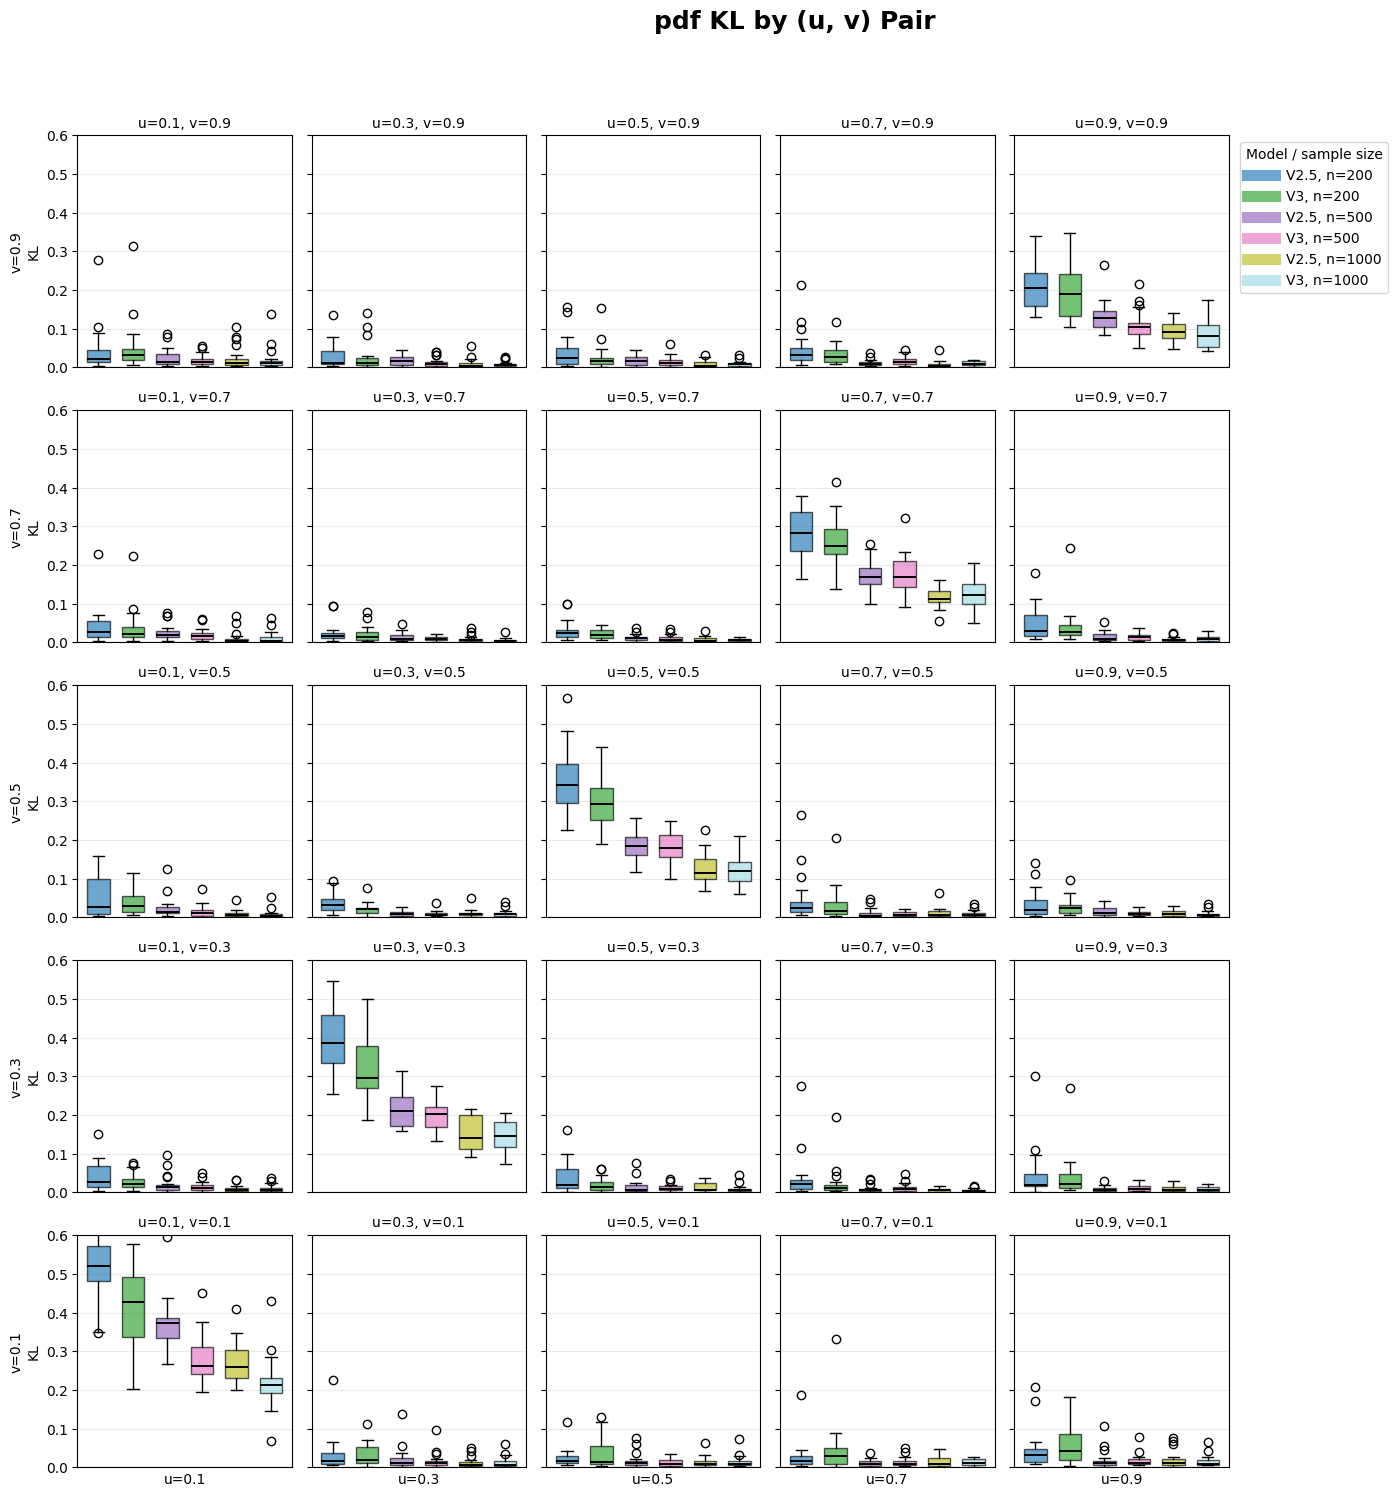

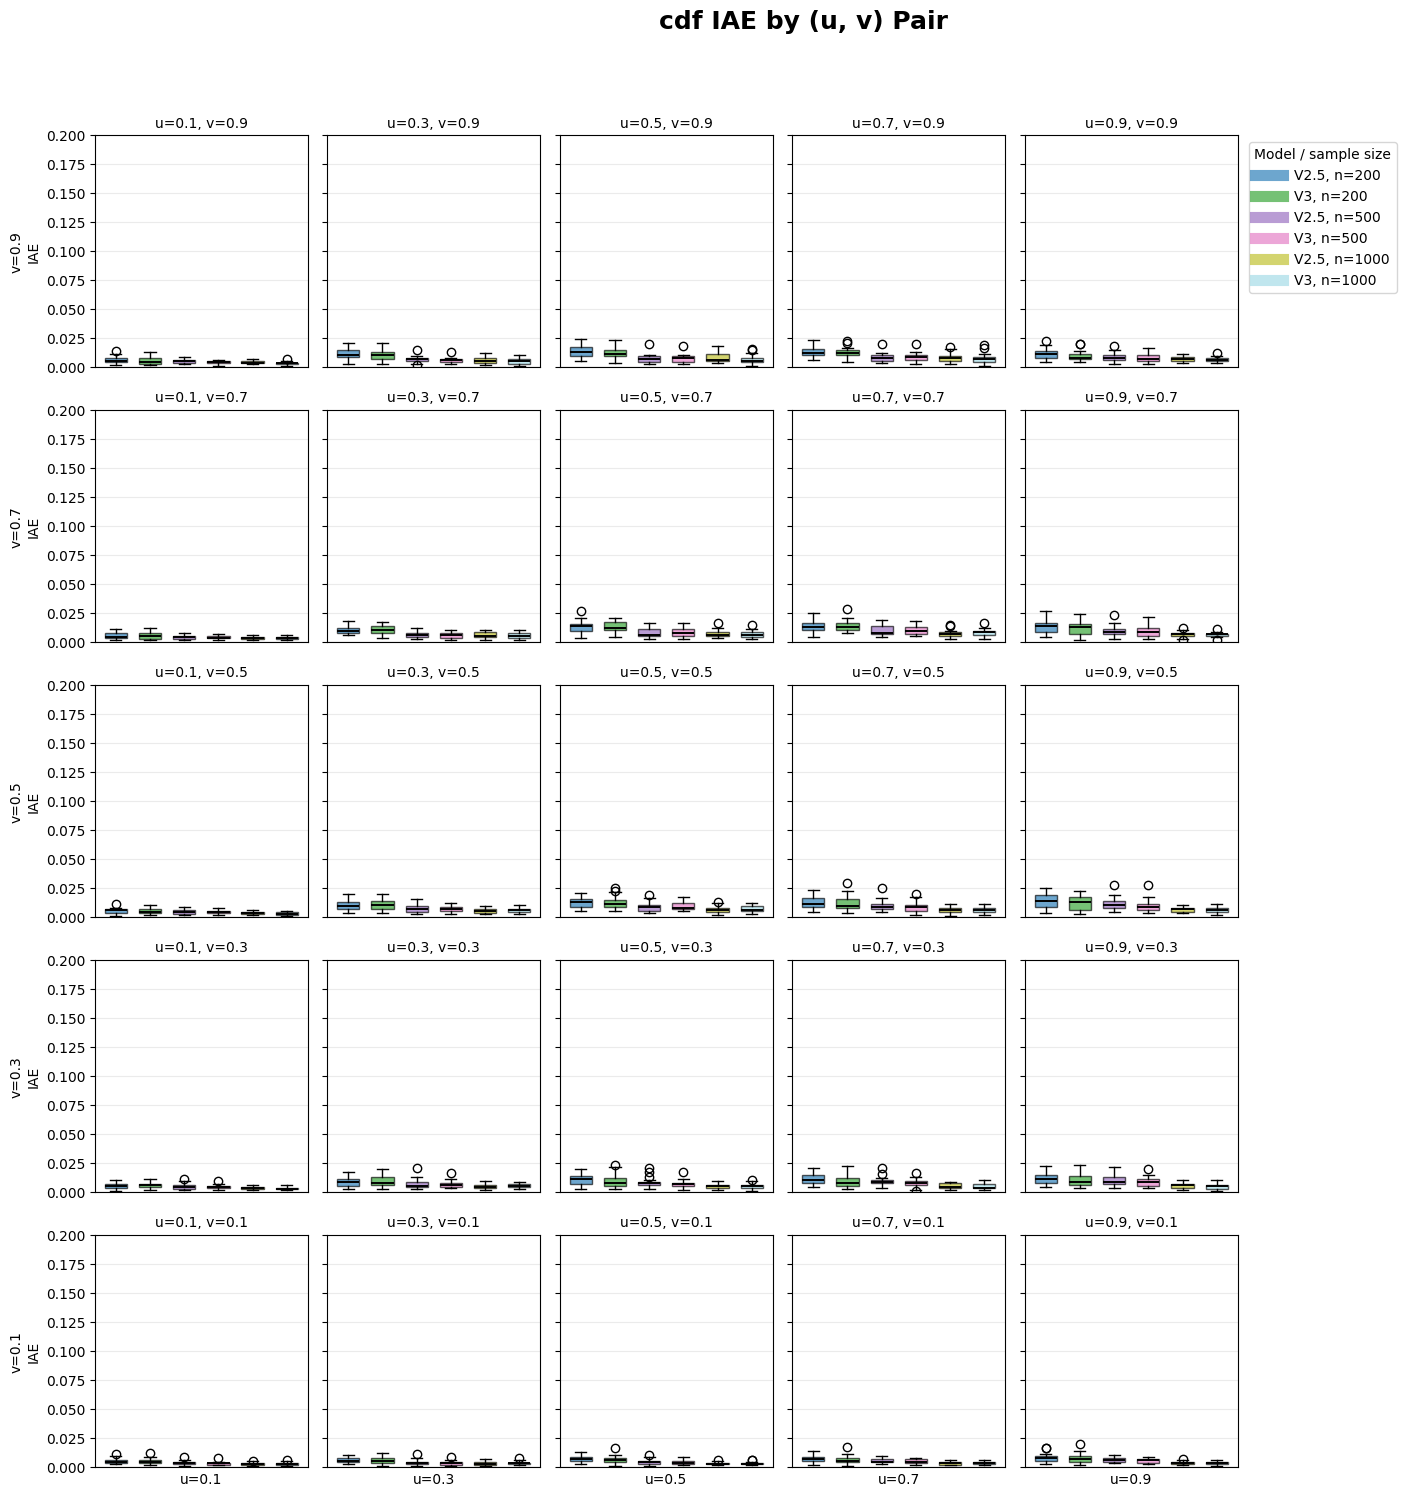

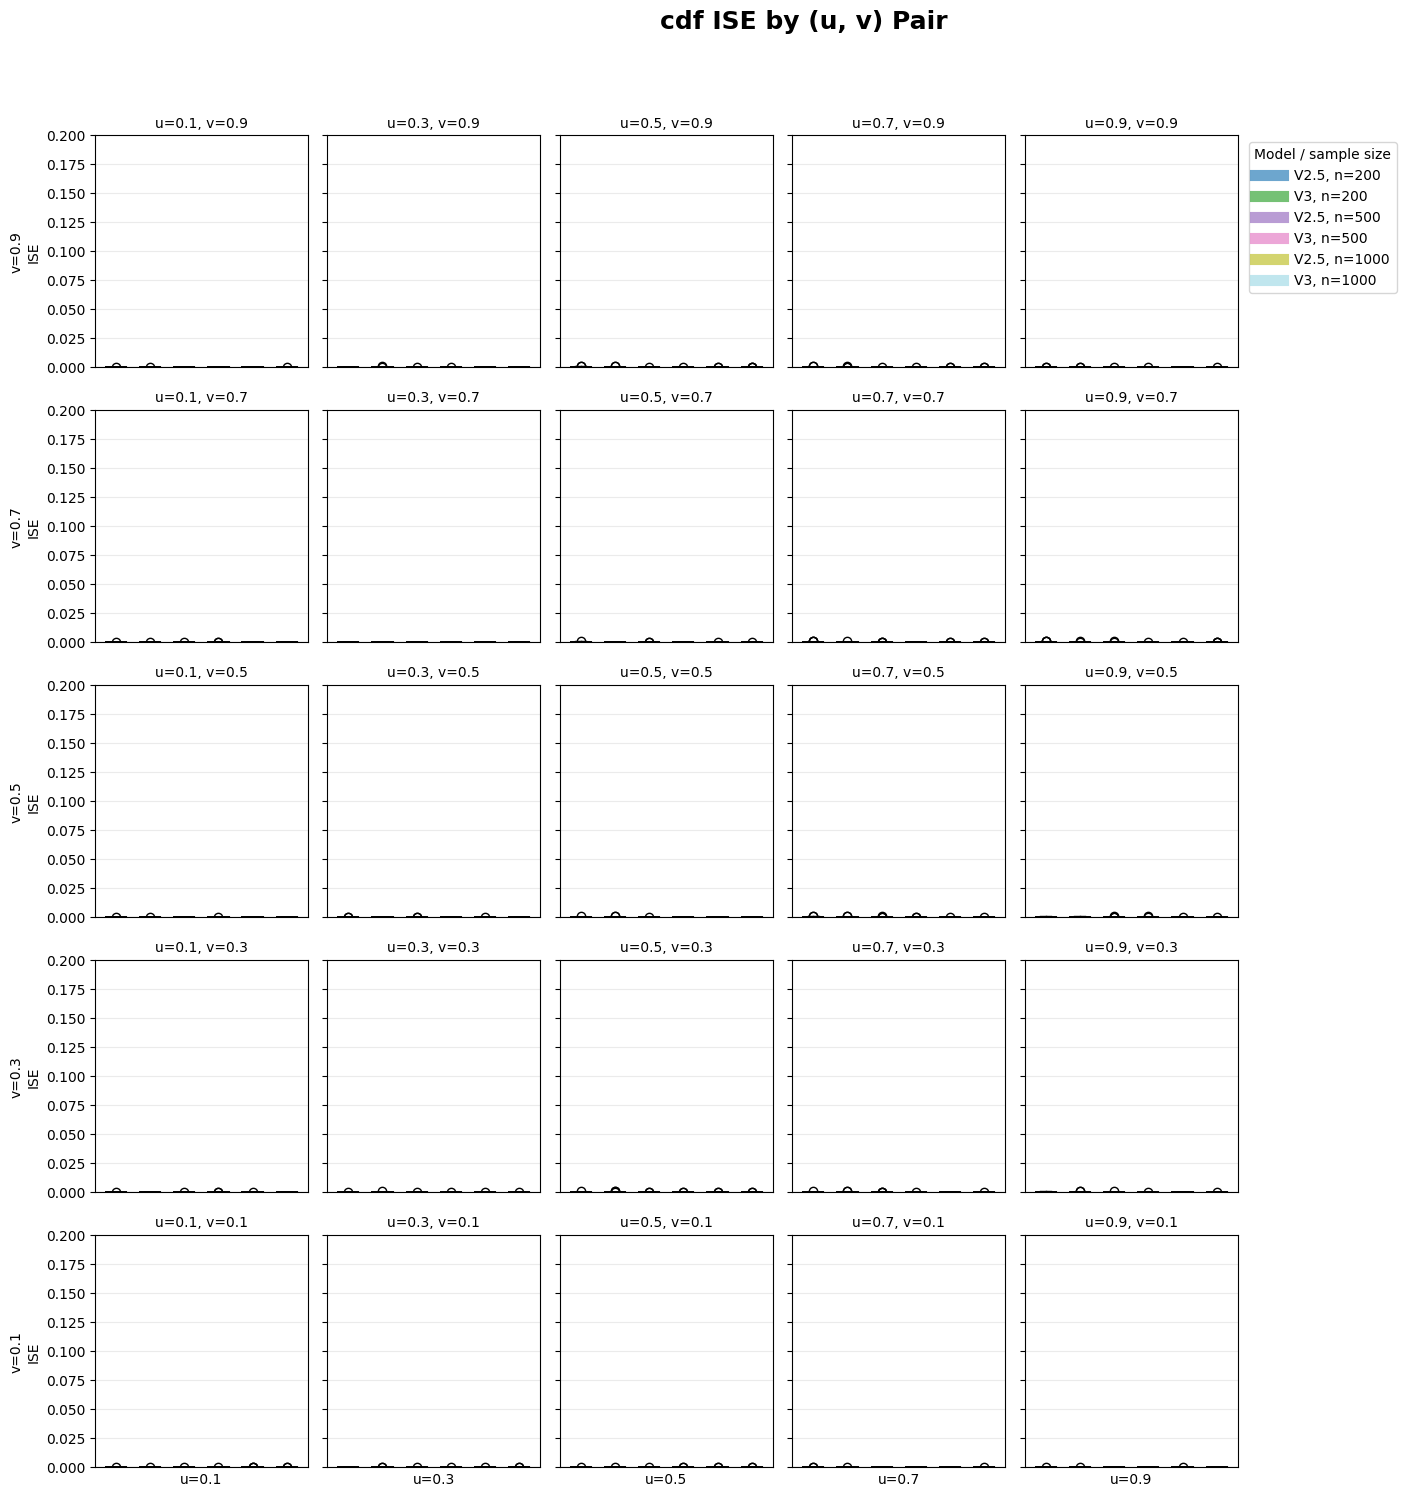

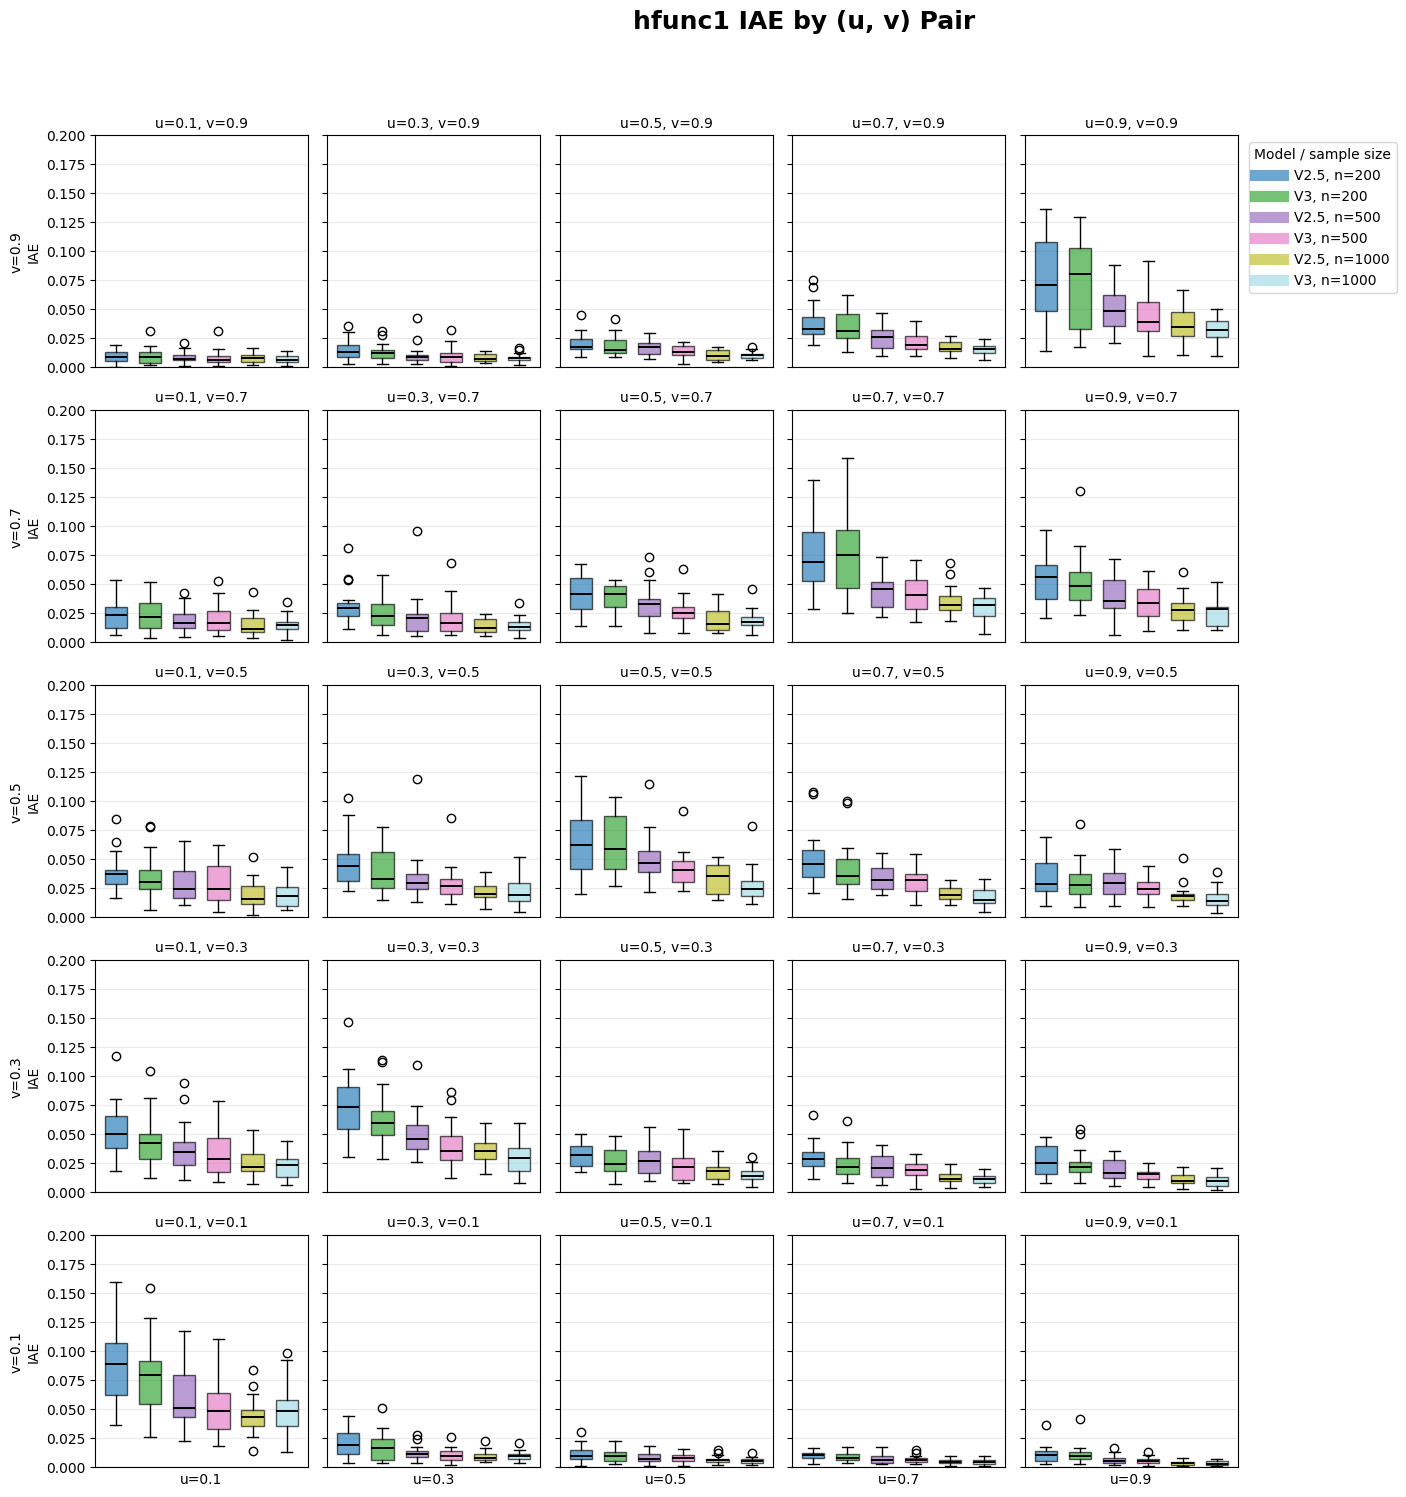

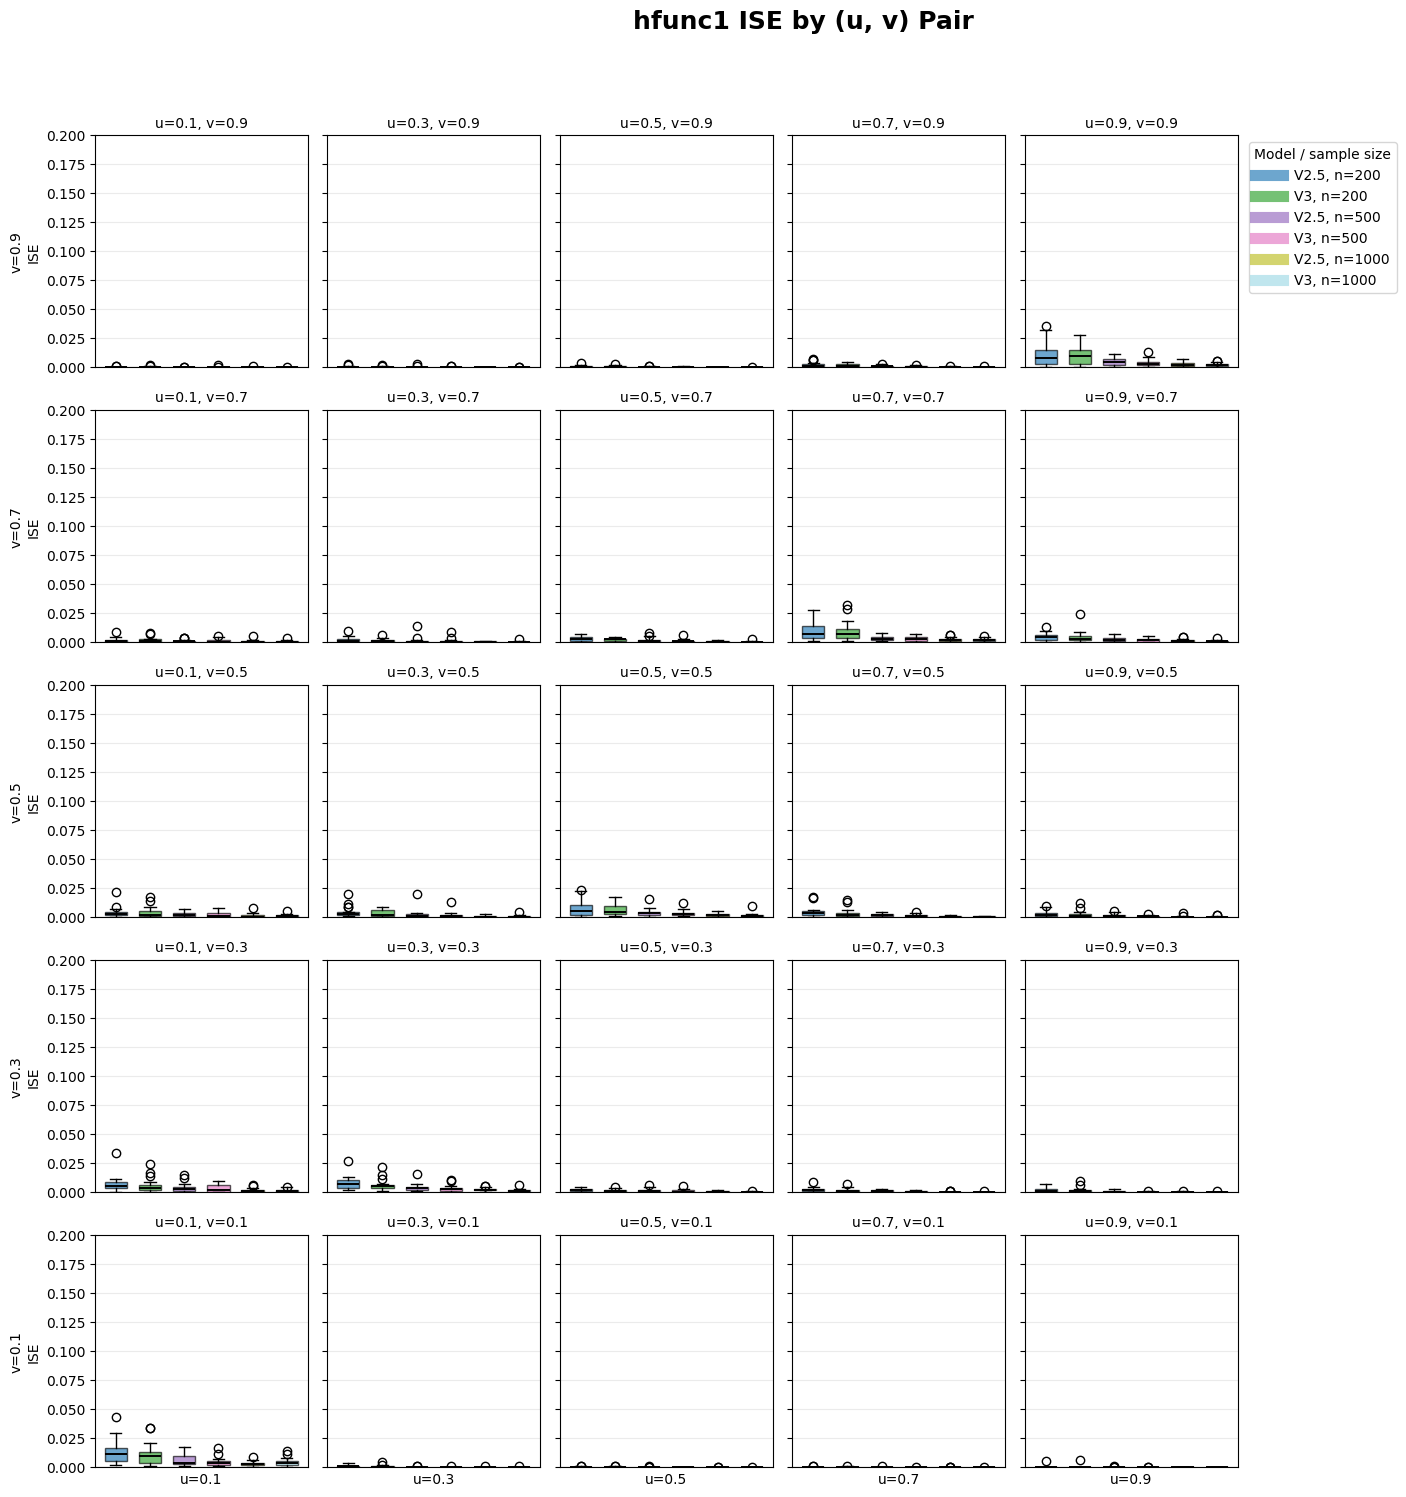

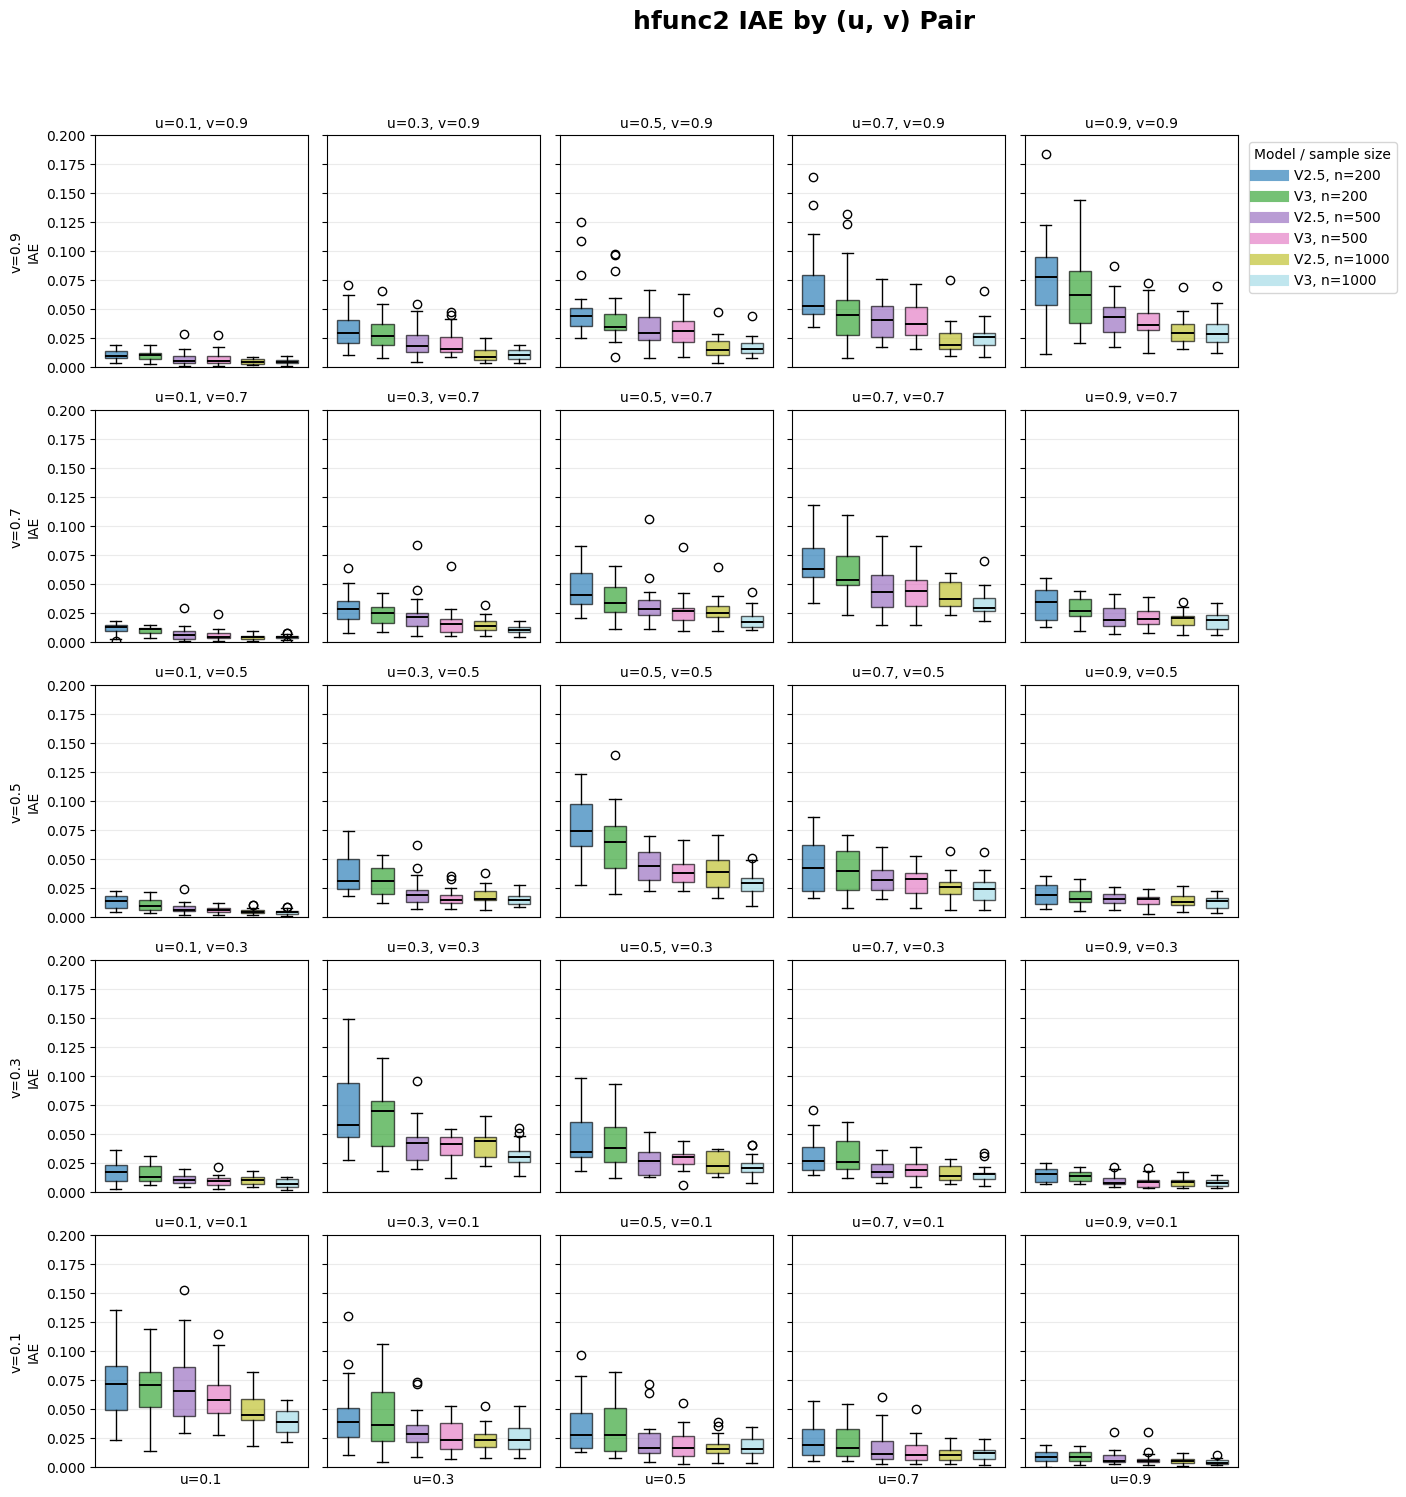

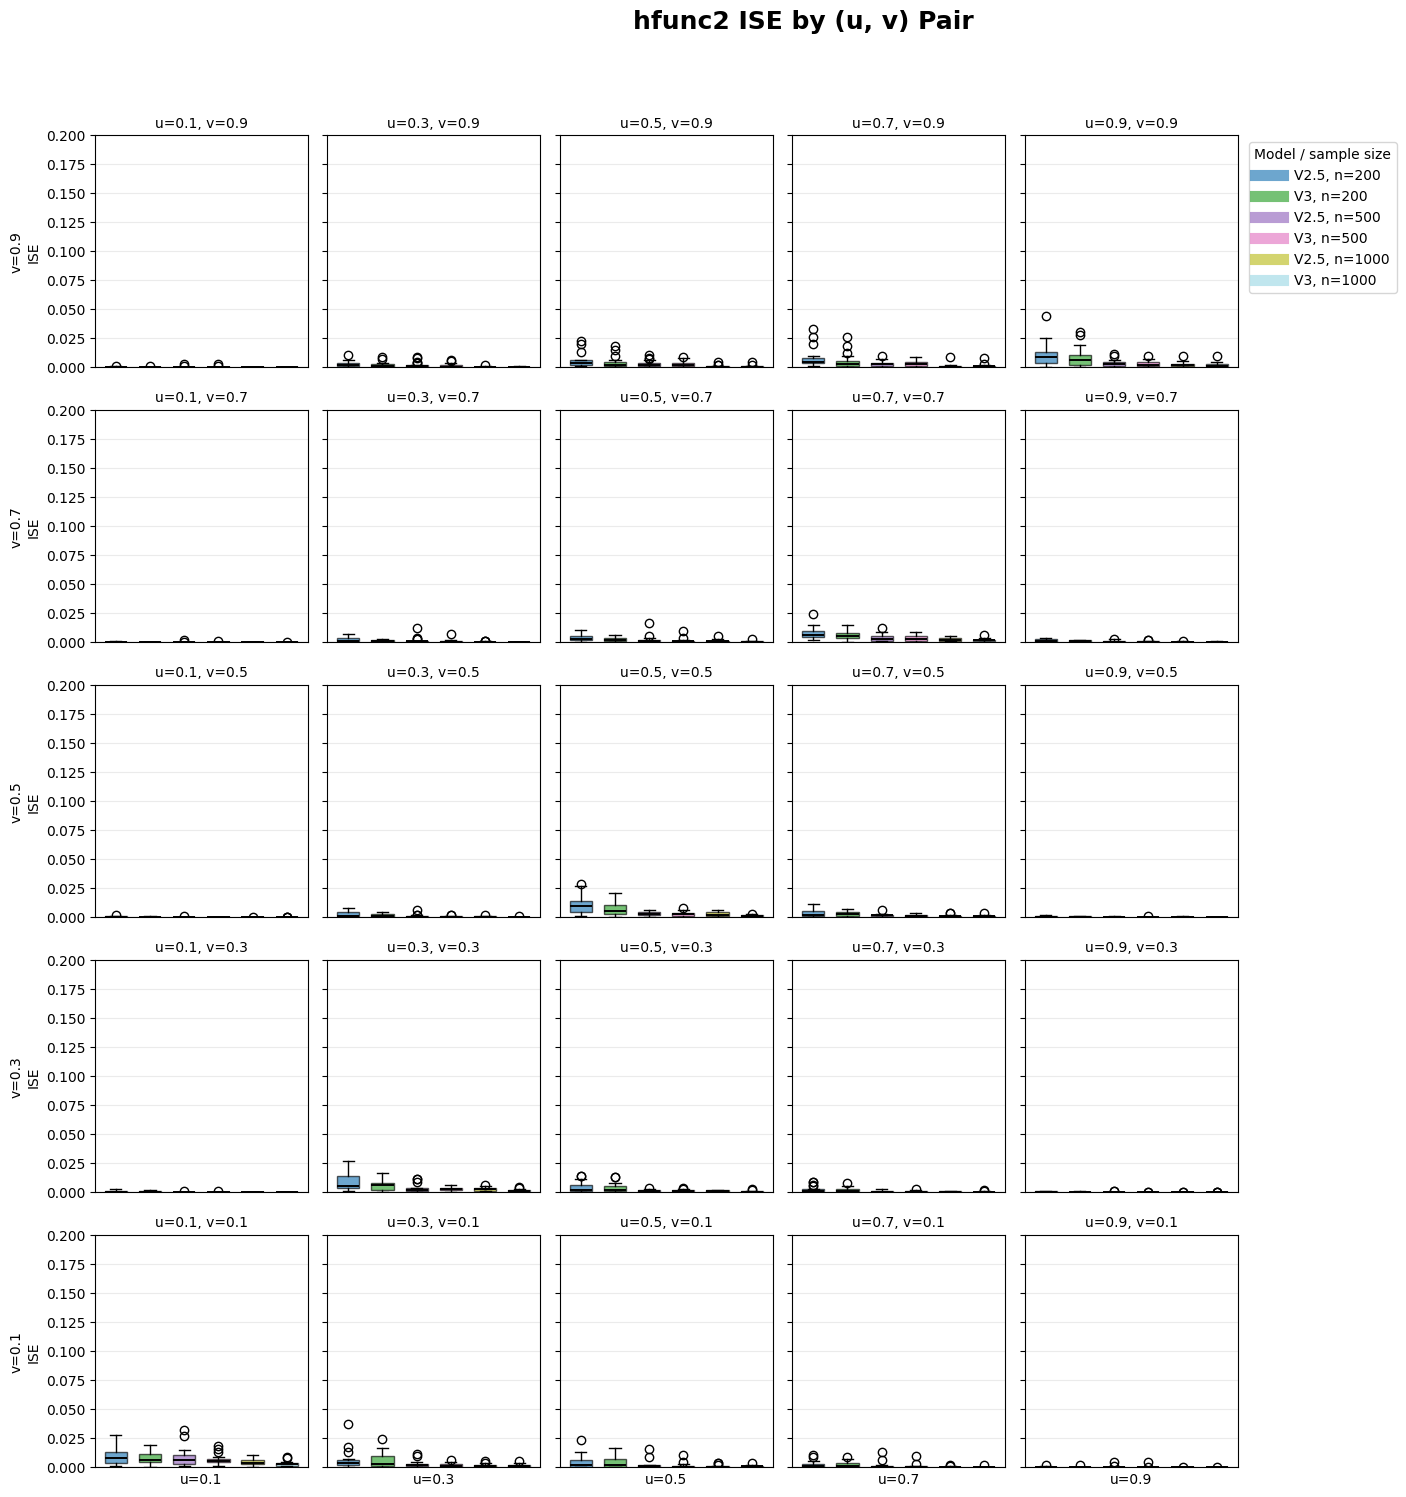

In [24]:
figs_axes = plot_all_uv_metric_boxgrids(
    rep_results,
    uv_pairs=uv_pairs,
    model_order=["V2.5", "V3"],
    metrics_by_quantity = {
        "pdf": ["KL"],
        "cdf": ["IAE", "ISE"],
        "hfunc1": ["IAE", "ISE"],
        "hfunc2": ["IAE", "ISE"],
    },
    ylim_by_metric={
        "IAE": (0.0, 0.2),
        "ISE": (0.0, 0.2),
        "KL": (0.0, 0.6),
    }
)
plt.show()

In [25]:
avg_uv_results = average_over_uv_pairs(rep_results)

avg_uv_summary = (
    avg_uv_results
    .groupby(["model", "n", "quantity"], as_index=False)
    .agg(
        IAE_mean=("IAE", "mean"),
        IAE_median=("IAE", "median"),
        ISE_mean=("ISE", "mean"),
        ISE_median=("ISE", "median"),
        KL_mean=("KL", "mean"),
        KL_median=("KL", "median"),
    )
)

display(avg_uv_summary)

,model,n,quantity,IAE_mean,IAE_median,ISE_mean,ISE_median,KL_mean,KL_median
0,V2.5,200,cdf,0.010287,0.010395,0.000228,0.000212,NaN,NaN
1,V2.5,200,hfunc1,0.039233,0.039771,0.003976,0.003897,NaN,NaN
2,V2.5,200,hfunc2,0.039607,0.040097,0.004174,0.003831,NaN,NaN
3,V2.5,200,pdf,0.923992,0.927526,129.418952,130.489080,0.101165,0.094953
4,V2.5,500,cdf,0.007494,0.006843,0.000121,0.000093,NaN,NaN
5,V2.5,500,hfunc1,0.028284,0.027104,0.002060,0.001730,NaN,NaN
6,V2.5,500,hfunc2,0.026805,0.027526,0.002023,0.001870,NaN,NaN
7,V2.5,500,pdf,0.715134,0.696168,111.984164,111.575996,0.056194,0.057232
8,V2.5,1000,cdf,0.005673,0.005749,0.000065,0.000062,NaN,NaN
9,V2.5,1000,hfunc1,0.019394,0.019816,0.001049,0.001025,NaN,NaN


In [26]:
avg_uv_summary_wide = avg_uv_summary.pivot_table(
    index=["n", "quantity"],
    columns="model",
    values=["IAE_mean", "ISE_mean", "KL_mean"],
)

avg_uv_summary_wide.columns = [
    f"{metric}_{model}" for metric, model in avg_uv_summary_wide.columns
]

avg_uv_summary_wide = avg_uv_summary_wide.reset_index()

display(avg_uv_summary_wide)

,n,quantity,IAE_mean_V2.5,IAE_mean_V3,ISE_mean_V2.5,ISE_mean_V3,KL_mean_V2.5,KL_mean_V3
0,200,cdf,0.010287,0.009760,0.000228,0.000210,NaN,NaN
1,200,hfunc1,0.039233,0.035545,0.003976,0.003368,NaN,NaN
2,200,hfunc2,0.039607,0.034974,0.004174,0.003239,NaN,NaN
3,200,pdf,0.923992,0.862939,129.418952,117.284323,0.101165,0.085990
4,500,cdf,0.007494,0.006995,0.000121,0.000103,NaN,NaN
5,500,hfunc1,0.028284,0.024583,0.002060,0.001612,NaN,NaN
6,500,hfunc2,0.026805,0.024120,0.002023,0.001624,NaN,NaN
7,500,pdf,0.715134,0.706325,111.984164,99.047882,0.056194,0.048816
8,1000,cdf,0.005673,0.005460,0.000065,0.000062,NaN,NaN
9,1000,hfunc1,0.019394,0.017899,0.001049,0.000935,NaN,NaN


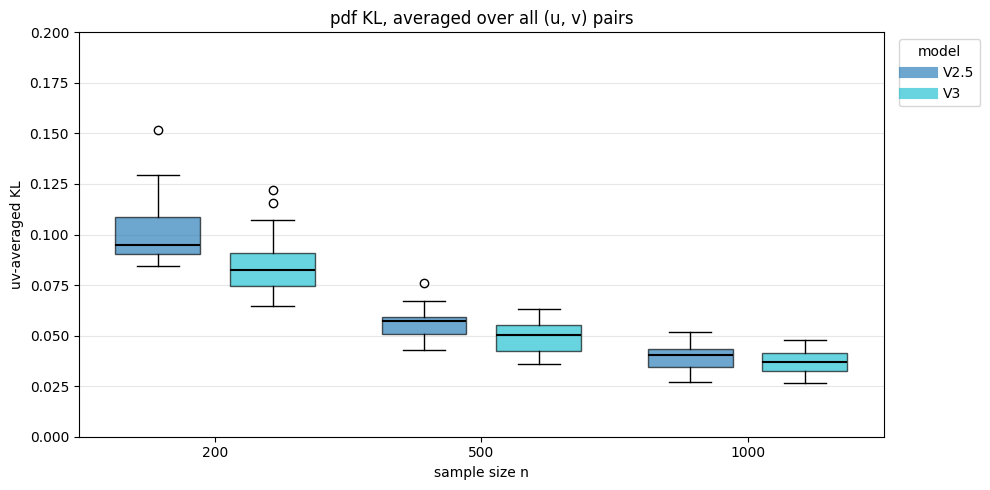

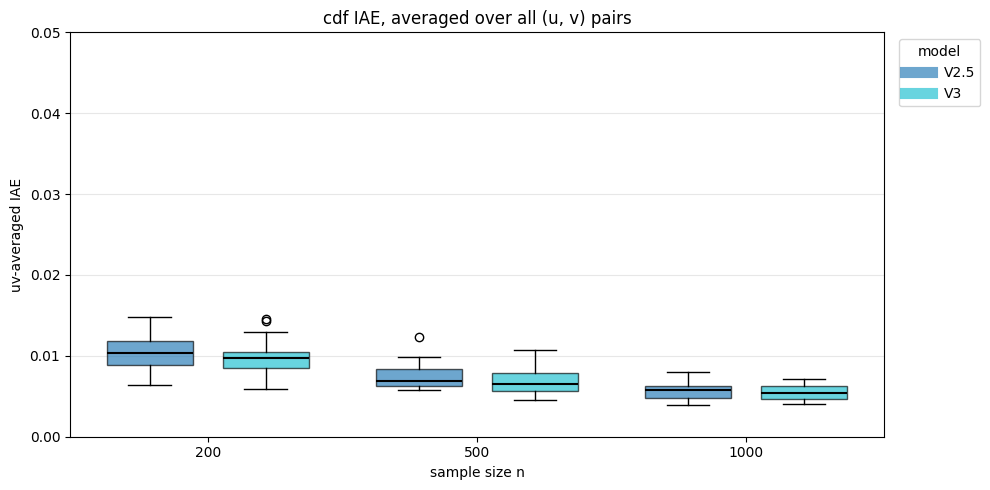

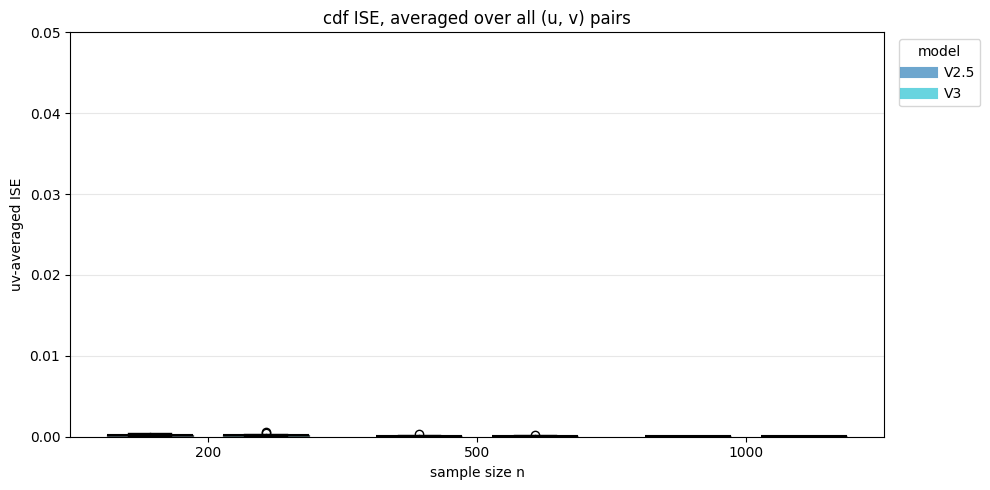

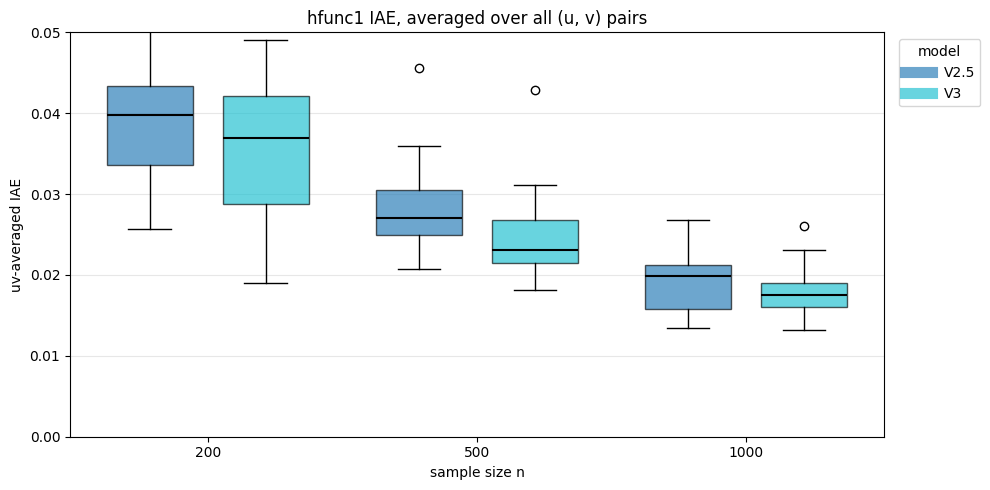

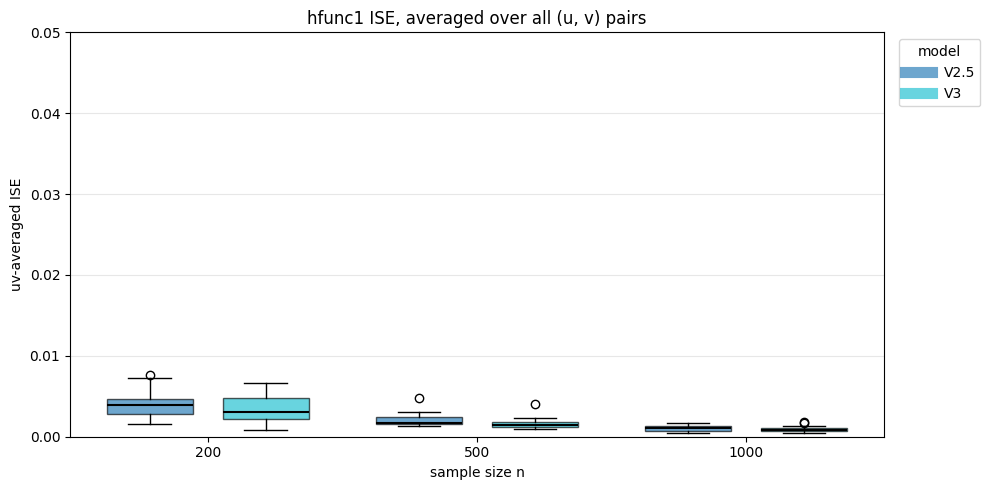

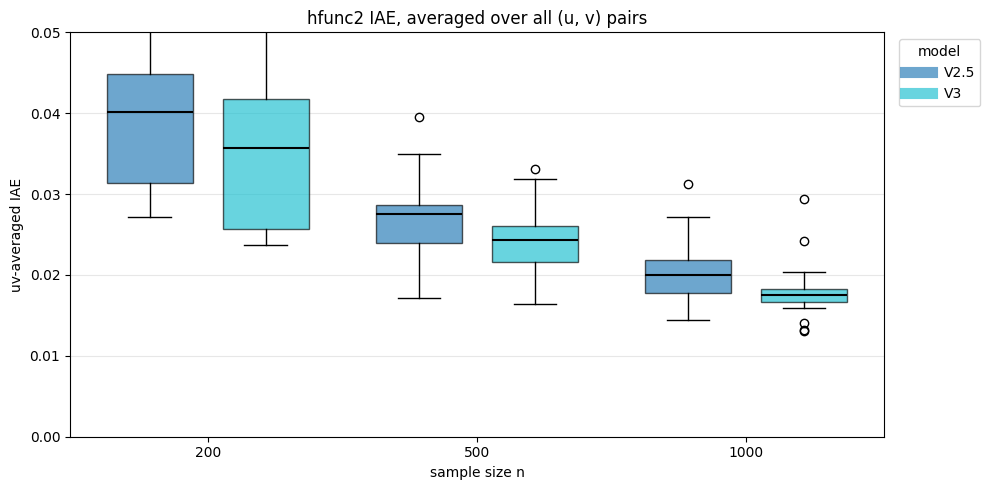

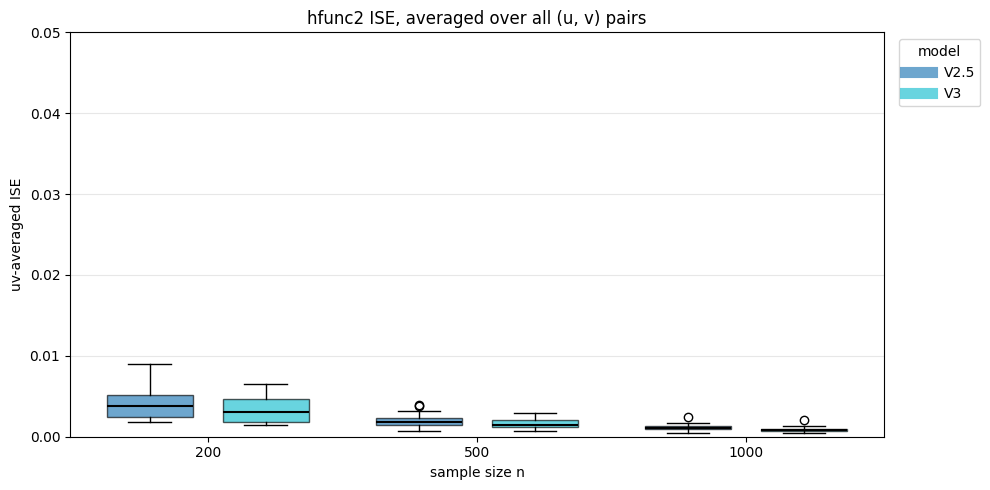

In [27]:
figs_axes = plot_all_avg_uv_metric_boxplots(
    rep_results,
    model_order=["V2.5", "V3"],
    metrics_by_quantity = {
        "pdf": ["KL"],
        "cdf": ["IAE", "ISE"],
        "hfunc1": ["IAE", "ISE"],
        "hfunc2": ["IAE", "ISE"],
    },
    ylim_by_metric={
        "IAE": (0.0, 0.05),
        "ISE": (0.0, 0.05),
        "KL": (0.0, 0.2),
    },
)

plt.show()

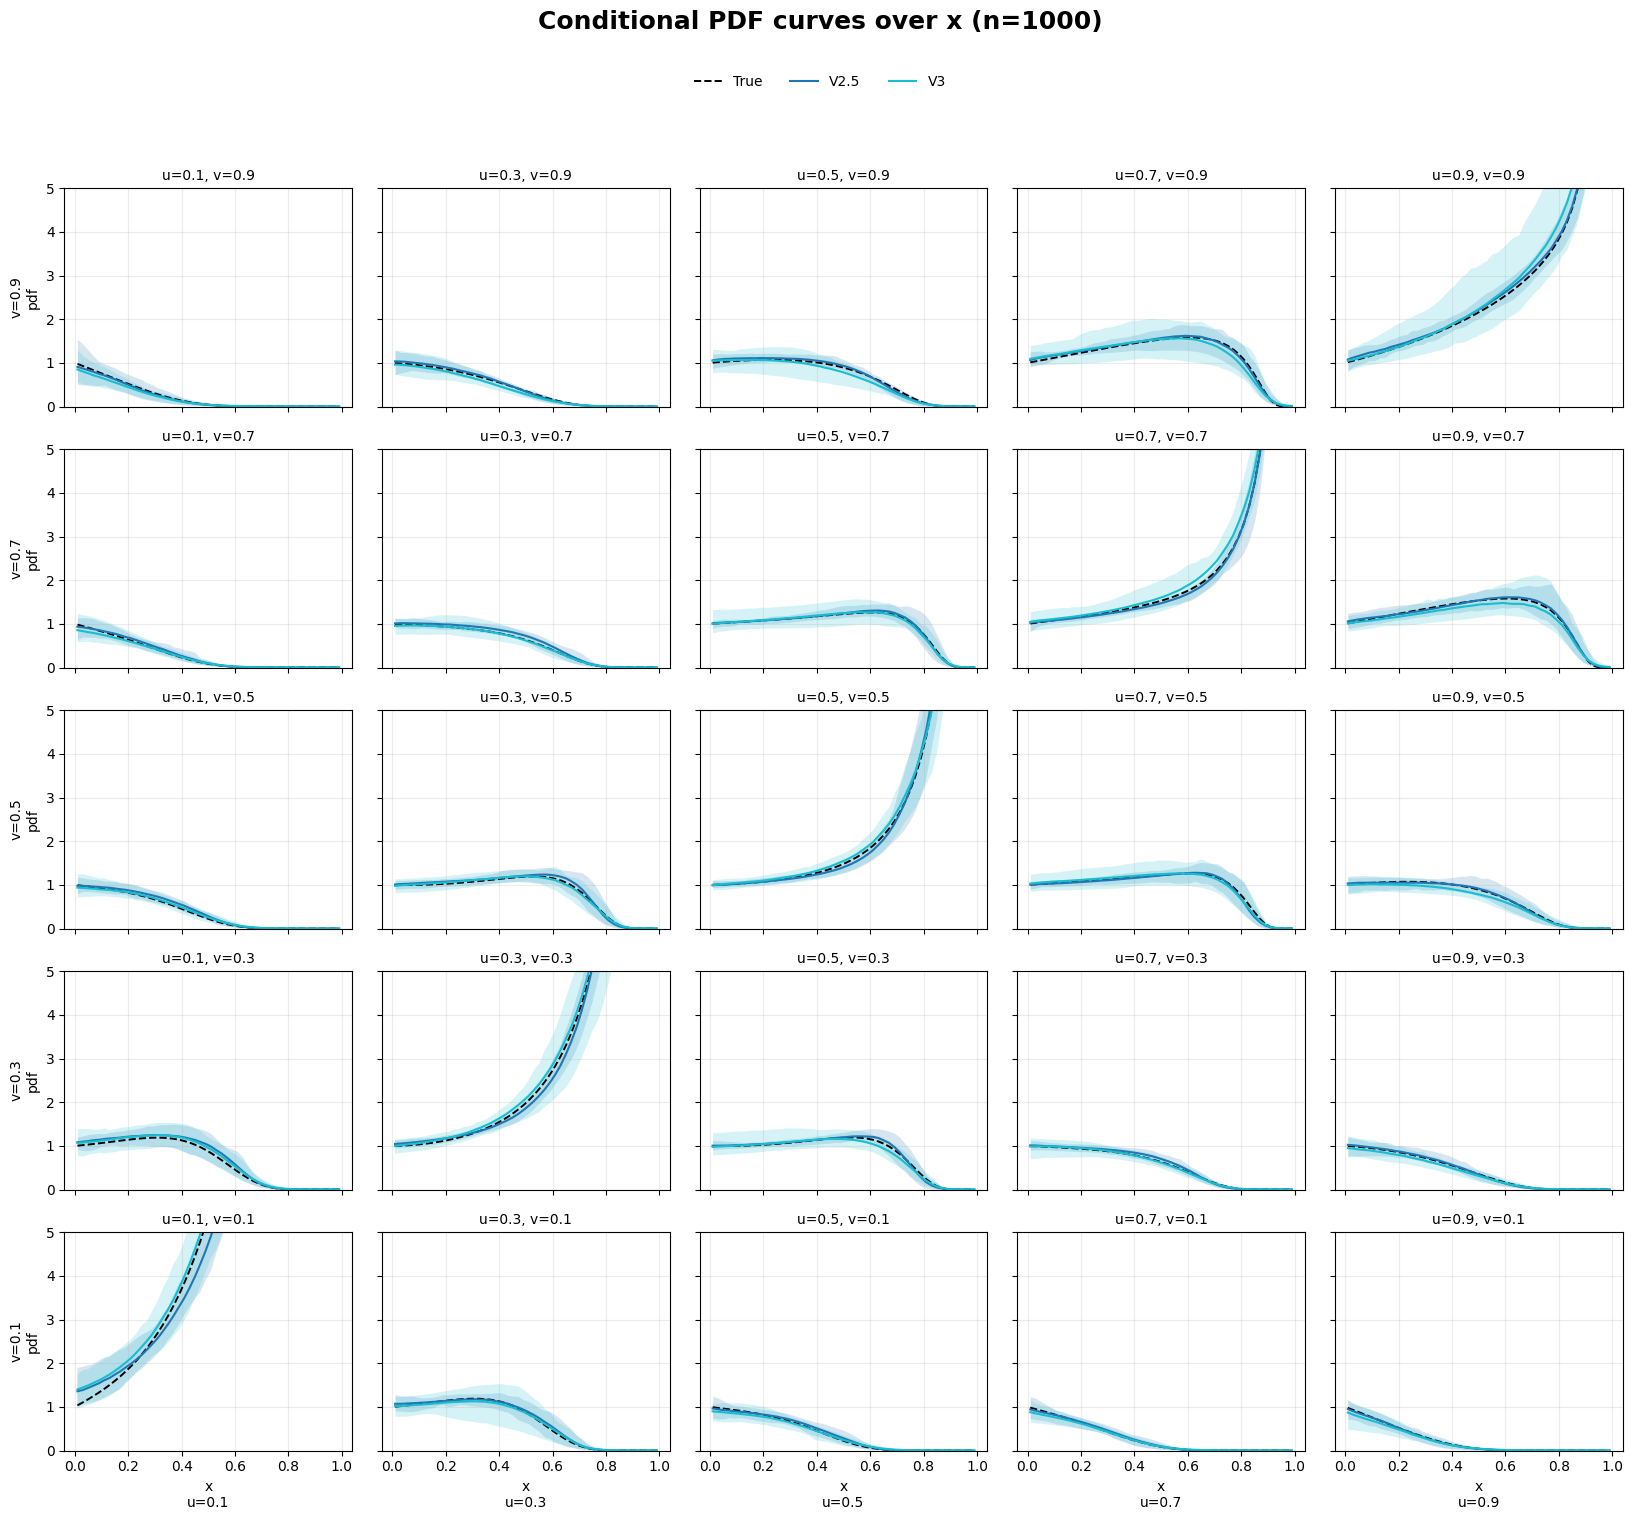

In [33]:
fig, axes = plot_conditional_curves_by_uv(
    pointwise_results,
    uv_pairs=uv_pairs,
    quantity="pdf",
    x_col="x",
    model_order=["V2.5", "V3"],
    n=1000,
    ylim=(0.0, 5.0),
    title="Conditional PDF curves over x",
)

plt.show()

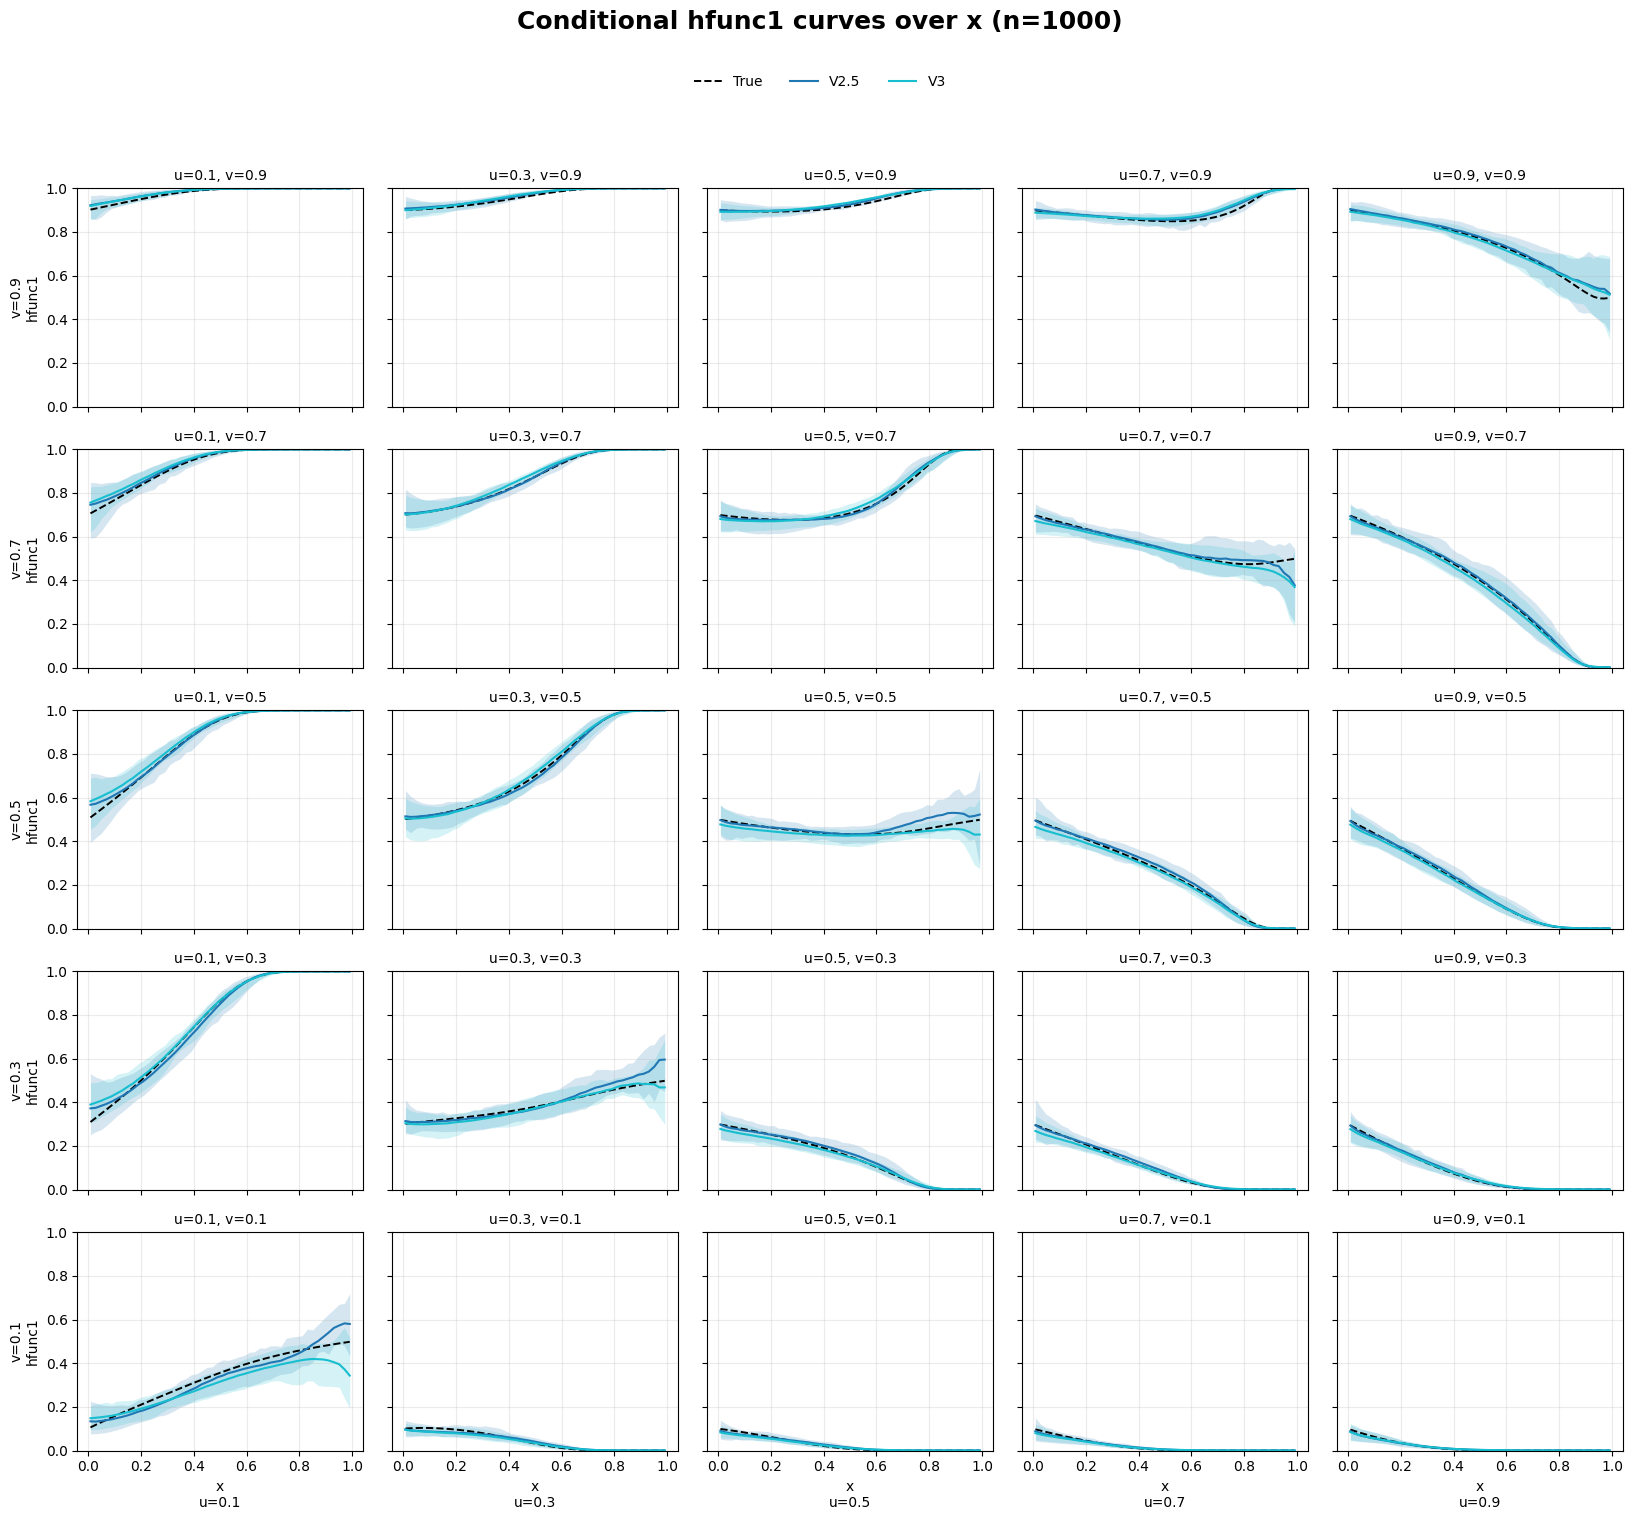

In [34]:
fig, axes = plot_conditional_curves_by_uv(
    pointwise_results,
    uv_pairs=uv_pairs,
    quantity="hfunc1",
    x_col="x",
    model_order=["V2.5", "V3"],
    n=1000,
    ylim=(0.0, 1.0),
    title="Conditional hfunc1 curves over x",
)

plt.show()